# Experiment 1 – LDA Evaluation

Post-hoc grid search over `n_topics` to justify the fixed parameters in `Experiment_1_LDA.ipynb`.

Pipeline: vectorize → fit LDA grid → coherence (c_v) + perplexity → penalized score → confidence distribution.

In [2]:
import importlib
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

In [3]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parents[2]

axis2_dir = PROJECT_ROOT / 'notebooks' / '03_Topic_and_Insights'
if str(axis2_dir) not in sys.path:
    sys.path.append(str(axis2_dir))

from Data_preprocessing import Parameters_Path as config
importlib.reload(config)

INPUT_PATH  = PROJECT_ROOT / 'data' / 'processed' / 'preprocessed_input.csv'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'Experiment_1_LDA'

count_cfg = config.PARAMETERS['count_vectorizer']
lda_cfg   = config.PARAMETERS['lda']

EVAL_N_TOPICS = [4, 6, 8, 10, 12, 16]
LAMBDA_COST   = 0.25
N_TOP_WORDS   = int(lda_cfg['n_top_words'])
RANDOM_STATE  = int(lda_cfg['random_state'])

In [4]:
df    = pd.read_csv(INPUT_PATH)
texts = df['text_cleaned_axis1'].astype(str).str.strip()
texts = texts[texts.ne('')]

vectorizer = CountVectorizer(
    max_df=count_cfg['max_df'],
    min_df=count_cfg['min_df'],
    max_features=count_cfg['max_features'],
    stop_words=count_cfg['stop_words']
)
X_count       = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()
tokenized     = [t.split() for t in texts]
dictionary    = Dictionary(tokenized)

print('Corpus:', X_count.shape)

Corpus: (8465, 1200)


## Grid Search

In [5]:
models, perplexities = {}, {}
for k in EVAL_N_TOPICS:
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=RANDOM_STATE,
        learning_method=lda_cfg['learning_method'],
        max_iter=lda_cfg['max_iter']
    )
    lda.fit(X_count)
    models[k] = lda
    perplexities[k] = lda.perplexity(X_count)
    print(f'n_topics={k}  perplexity={perplexities[k]:.2f}')

n_topics=4  perplexity=270.81
n_topics=6  perplexity=266.36
n_topics=8  perplexity=253.16
n_topics=10  perplexity=241.14
n_topics=12  perplexity=229.28
n_topics=16  perplexity=217.05


In [6]:
rows = []
for k, lda in models.items():
    topic_words = [
        [feature_names[i] for i in topic.argsort()[-N_TOP_WORDS:][::-1]]
        for topic in lda.components_
    ]
    coherence = CoherenceModel(
        topics=topic_words, texts=tokenized,
        dictionary=dictionary, coherence='c_v'
    ).get_coherence()
    rows.append({'n_topics': k, 'coherence_cv': coherence, 'perplexity': perplexities[k]})

metrics_df = pd.DataFrame(rows)
metrics_df

,n_topics,coherence_cv,perplexity
0,4,0.419799,270.811977
1,6,0.493347,266.363710
2,8,0.551766,253.158454
3,10,0.638065,241.144194
4,12,0.604867,229.280759
5,16,0.644796,217.047233


## Penalized Score

`score = coherence_norm − λ × topic_cost_norm`  
Higher is better; λ controls the complexity penalty.

In [7]:
coh = metrics_df['coherence_cv']
k_  = metrics_df['n_topics']

metrics_df['coh_norm']  = (coh - coh.min()) / (coh.max() - coh.min())
metrics_df['cost_norm'] = (k_  - k_.min())  / (k_.max()  - k_.min())
metrics_df['penalized'] = metrics_df['coh_norm'] - LAMBDA_COST * metrics_df['cost_norm']

best_k = int(metrics_df.loc[metrics_df['penalized'].idxmax(), 'n_topics'])
print(f"Best n_topics: {best_k}")

metrics_df.to_csv(RESULTS_DIR / 'Experiment_1_lda_eval_metrics.csv', index=False)
metrics_df

Best n_topics: 10


,n_topics,coherence_cv,perplexity,coh_norm,cost_norm,penalized
0,4,0.419799,270.811977,0.000000,0.000000,0.000000
1,6,0.493347,266.363710,0.326886,0.166667,0.285219
2,8,0.551766,253.158454,0.586529,0.333333,0.503196
3,10,0.638065,241.144194,0.970084,0.500000,0.845084
4,12,0.604867,229.280759,0.822534,0.666667,0.655867
5,16,0.644796,217.047233,1.000000,1.000000,0.750000


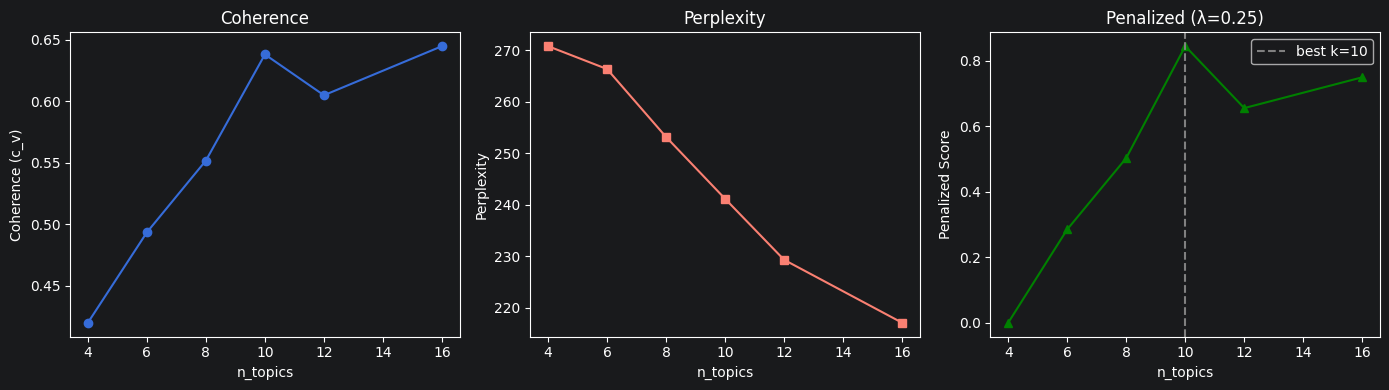

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(metrics_df['n_topics'], metrics_df['coherence_cv'], marker='o')
axes[0].set_xlabel('n_topics'); axes[0].set_ylabel('Coherence (c_v)'); axes[0].set_title('Coherence')

axes[1].plot(metrics_df['n_topics'], metrics_df['perplexity'], marker='s', color='salmon')
axes[1].set_xlabel('n_topics'); axes[1].set_ylabel('Perplexity'); axes[1].set_title('Perplexity')

axes[2].plot(metrics_df['n_topics'], metrics_df['penalized'], marker='^', color='green')
axes[2].axvline(best_k, linestyle='--', color='gray', label=f'best k={best_k}')
axes[2].set_xlabel('n_topics'); axes[2].set_ylabel('Penalized Score'); axes[2].set_title(f'Penalized (λ={LAMBDA_COST})')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'Experiment_1_lda_eval_metrics.png')
plt.show()

## Confidence Distribution

Per-document dominant-topic probability from the fixed-config model output.

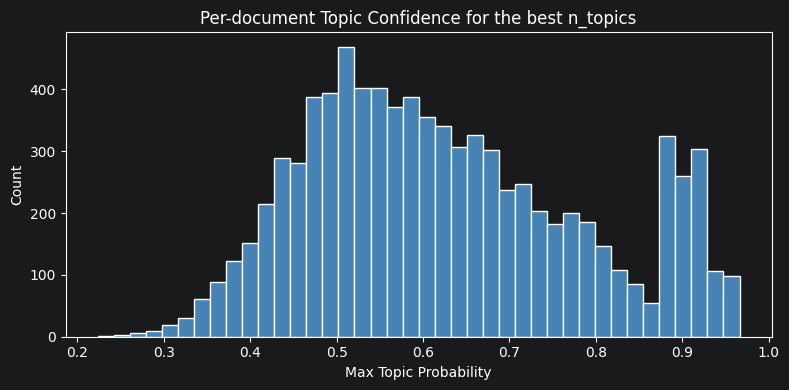

count    8465.000000
mean        0.627165
std         0.159413
min         0.223560
25%         0.504557
50%         0.601791
75%         0.737413
max         0.966331
Name: max_topic_prob, dtype: float64

In [11]:
doc_topic_df = pd.read_csv(RESULTS_DIR / 'Experiment_1_lda_doc_topics.csv')

plt.figure(figsize=(8, 4))
plt.hist(doc_topic_df['max_topic_prob'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Max Topic Probability')
plt.ylabel('Count')
plt.title(f'Per-document Topic Confidence for the best n_topics')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'Experiment_1_lda_confidence_dist.png')
plt.show()

doc_topic_df['max_topic_prob'].describe()